In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Libraries loaded successfully!")

TensorFlow version: 2.20.0
NumPy version: 2.1.3
Libraries loaded successfully!


In [2]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


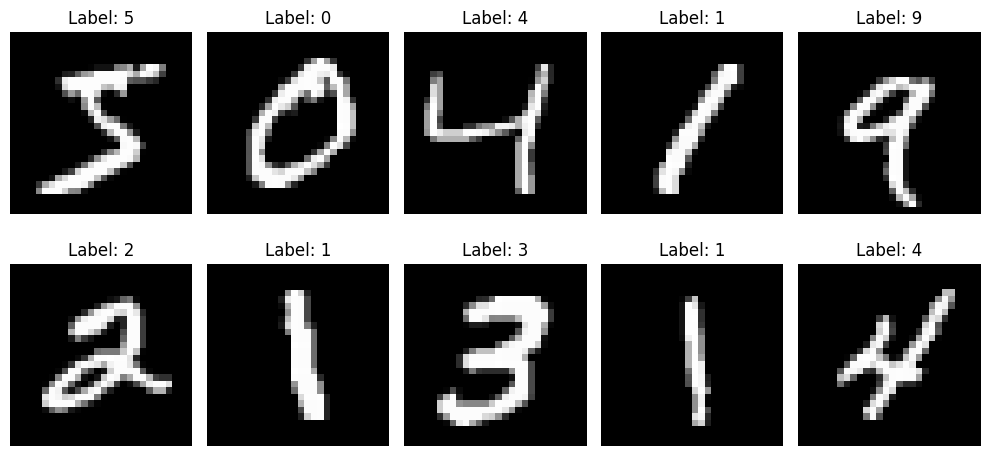

In [3]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [5]:
unique, counts = np.unique(y_train, return_counts=True)

print("Digit distribution:\n")

for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} images")

Digit distribution:

Digit 0: 5923 images
Digit 1: 6742 images
Digit 2: 5958 images
Digit 3: 6131 images
Digit 4: 5842 images
Digit 5: 5421 images
Digit 6: 5918 images
Digit 7: 6265 images
Digit 8: 5851 images
Digit 9: 5949 images


In [6]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Input layer
    layers.Input(shape=(28, 28, 1)),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps to a vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Prevent overfitting
    layers.Dropout(0.30),

    # Output layer: digits 0-9
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "/content/handwritten_digit_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.10,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.8118 - loss: 0.6100
Epoch 1: val_accuracy improved from None to 0.98467, saving model to /content/handwritten_digit_cnn.keras

Epoch 1: finished saving model to /content/handwritten_digit_cnn.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 60s 138ms/step - accuracy: 0.9167 - loss: 0.2730 - val_accuracy: 0.9847 - val_loss: 0.0544
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9766 - loss: 0.0794
Epoch 2: val_accuracy improved from 0.98467 to 0.98700, saving model to /content/handwritten_digit_cnn.keras

Epoch 2: finished saving model to /content/handwritten_digit_cnn.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 57s 136ms/step - accuracy: 0.9780 - loss: 0.0730 - val_accuracy: 0.9870 - val_loss: 0.0425
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9834 - loss: 0.0525
Epoch 3: val_accuracy improved from 0.98700 to 0.98983, saving model to /content/handwritten_digit_cnn.keras

Epoch 3: finished saving mo

In [9]:
# Evaluate the trained model on completely unseen test data

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9920 - loss: 0.0240

FINAL TEST RESULTS
Test Loss     : 0.0240
Test Accuracy : 99.20%


In [10]:
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions generated successfully!")
print("Prediction shape:", y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Predictions generated successfully!
Prediction shape: (10000,)


In [11]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    digits=4
))

              precision    recall  f1-score   support

           0     0.9949    0.9929    0.9939       980
           1     0.9947    0.9965    0.9956      1135
           2     0.9894    0.9942    0.9918      1032
           3     0.9941    0.9941    0.9941      1010
           4     0.9899    0.9939    0.9919       982
           5     0.9921    0.9899    0.9910       892
           6     0.9958    0.9906    0.9932       958
           7     0.9922    0.9874    0.9898      1028
           8     0.9888    0.9928    0.9908       974
           9     0.9881    0.9871    0.9876      1009

    accuracy                         0.9920     10000
   macro avg     0.9920    0.9919    0.9920     10000
weighted avg     0.9920    0.9920    0.9920     10000



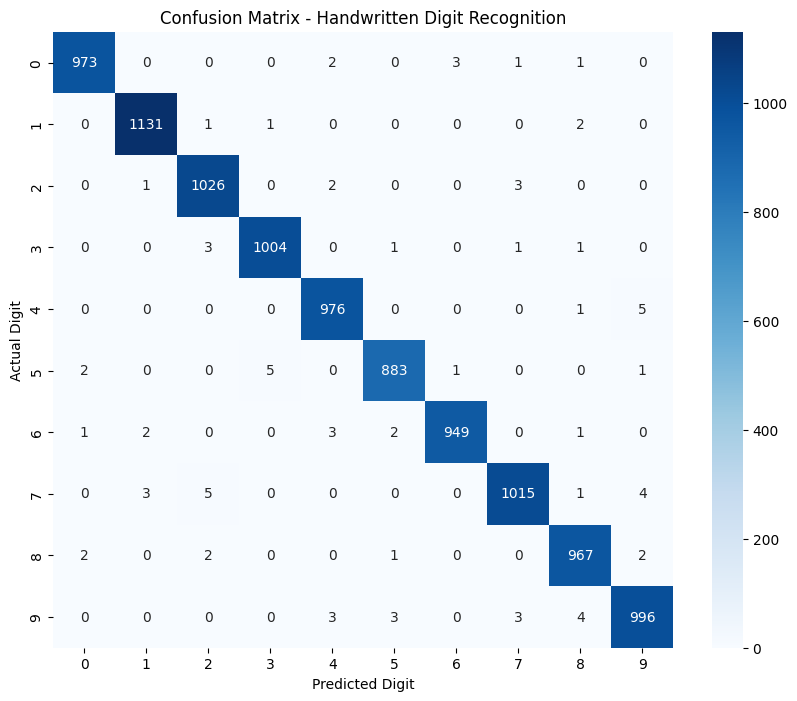

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("Confusion Matrix - Handwritten Digit Recognition")
plt.show()

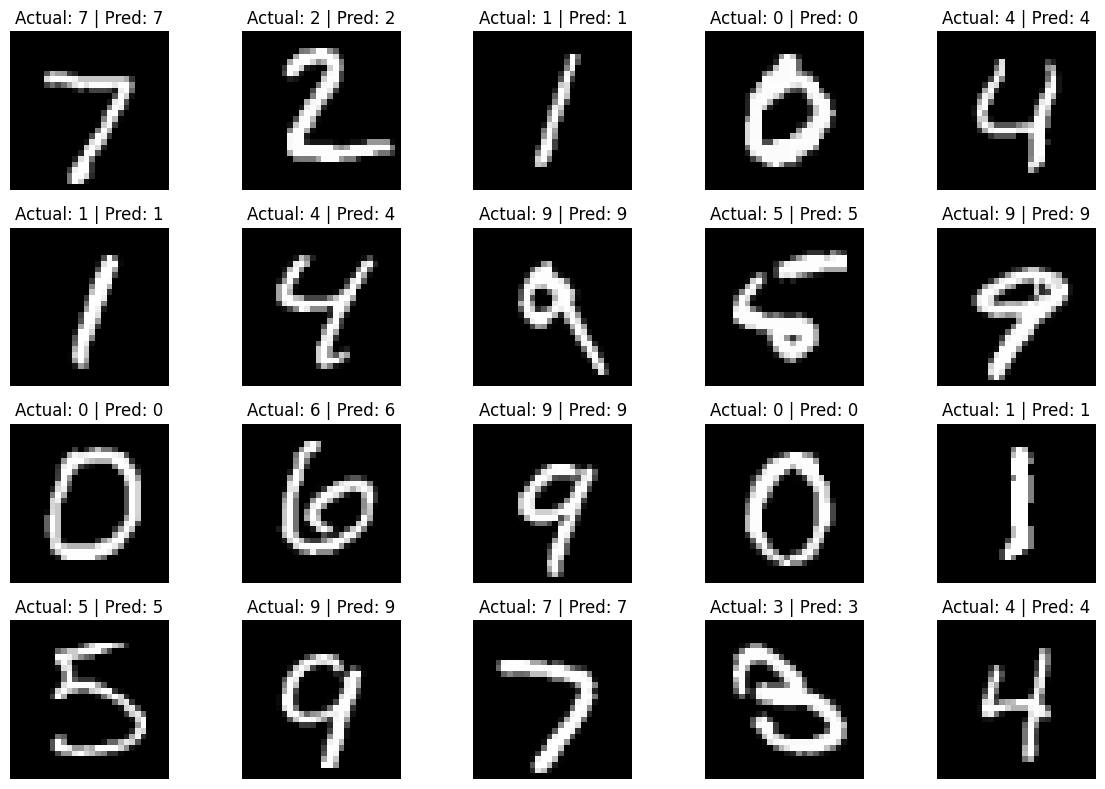

In [13]:
plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    plt.imshow(X_test[i].squeeze(), cmap="gray")

    actual = y_test[i]
    predicted = y_pred[i]

    plt.title(
        f"Actual: {actual} | Pred: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

DIGIT PREDICTION
Actual Digit    : 7
Predicted Digit : 7
Confidence      : 100.00%


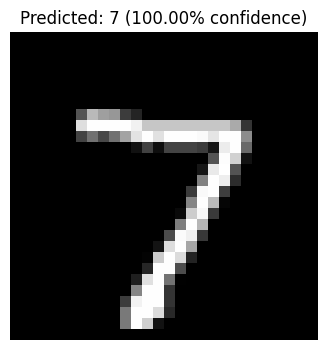

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Select one test image
index = 0

image = X_test[index]
actual_digit = y_test[index]

# Add batch dimension for prediction
prediction = model.predict(
    np.expand_dims(image, axis=0),
    verbose=0
)

predicted_digit = np.argmax(prediction[0])
confidence = np.max(prediction[0]) * 100

print("==============================")
print("DIGIT PREDICTION")
print("==============================")
print(f"Actual Digit    : {actual_digit}")
print(f"Predicted Digit : {predicted_digit}")
print(f"Confidence      : {confidence:.2f}%")

# Display image
plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(
    f"Predicted: {predicted_digit} "
    f"({confidence:.2f}% confidence)"
)
plt.axis("off")
plt.show()

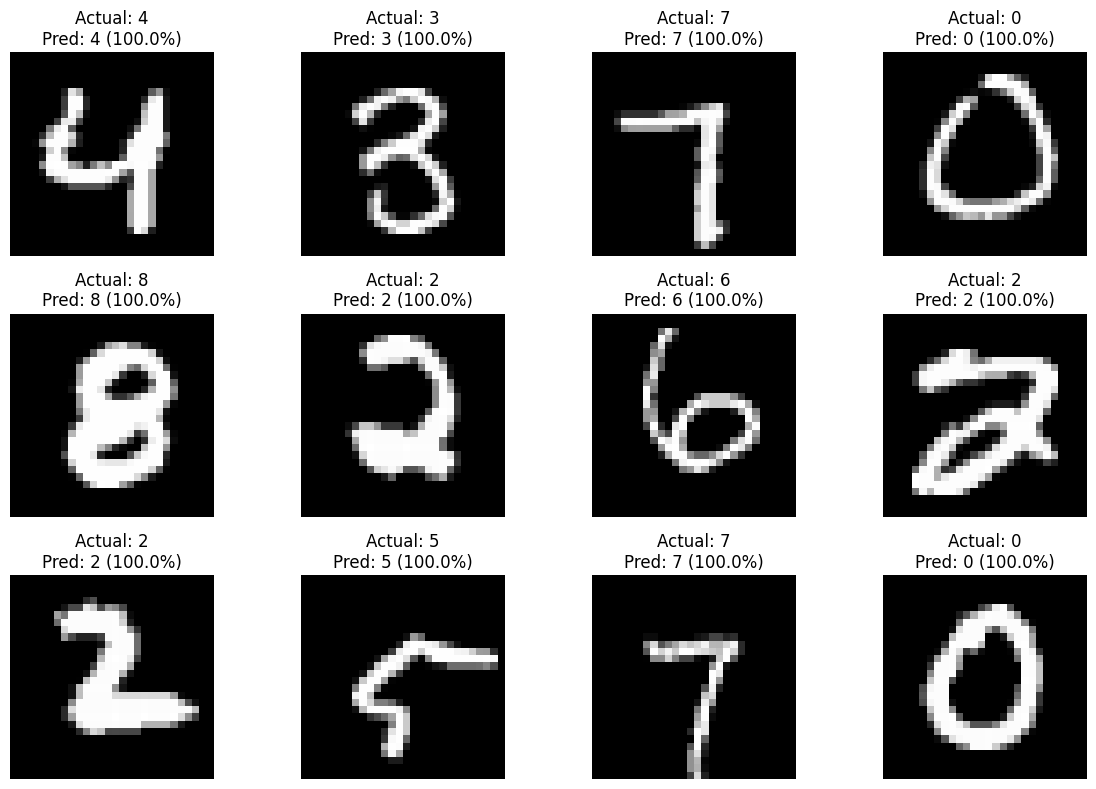

In [15]:
import random

plt.figure(figsize=(12, 8))

for i in range(12):

    index = random.randint(0, len(X_test) - 1)

    image = X_test[index]
    actual = y_test[index]

    prediction = model.predict(
        np.expand_dims(image, axis=0),
        verbose=0
    )

    predicted = np.argmax(prediction[0])
    confidence = np.max(prediction[0]) * 100

    plt.subplot(3, 4, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")

    plt.title(
        f"Actual: {actual}\n"
        f"Pred: {predicted} ({confidence:.1f}%)"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Save the final trained CNN model

model.save("/content/handwritten_digit_cnn.keras")

print("Model saved successfully!")
print("File: /content/handwritten_digit_cnn.keras")

Model saved successfully!
File: /content/handwritten_digit_cnn.keras


In [17]:
%%writefile /content/app.py

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# -----------------------------
# Page configuration
# -----------------------------
st.set_page_config(
    page_title="Handwritten Digit Recognition",
    page_icon="🔢",
    layout="centered"
)

# -----------------------------
# Load trained model
# -----------------------------
@st.cache_resource
def load_model():
    return tf.keras.models.load_model(
        "handwritten_digit_cnn.keras"
    )

model = load_model()

# -----------------------------
# Title
# -----------------------------
st.title("🔢 Handwritten Digit Recognition")
st.write(
    "Upload an image of a handwritten digit and "
    "the CNN model will predict the digit."
)

st.divider()

# -----------------------------
# Upload image
# -----------------------------
uploaded_file = st.file_uploader(
    "Upload a handwritten digit image",
    type=["png", "jpg", "jpeg"]
)

if uploaded_file is not None:

    # Open image
    image = Image.open(uploaded_file).convert("L")

    st.subheader("Uploaded Image")
    st.image(
        image,
        width=200
    )

    # Convert to numpy
    image_array = np.array(image)

    # Resize
    image_resized = Image.fromarray(
        image_array
    ).resize((28, 28))

    image_array = np.array(
        image_resized
    ).astype("float32")

    # Automatically handle white-background images
    if image_array.mean() > 127:
        image_array = 255 - image_array

    # Normalize
    image_array = image_array / 255.0

    # Add dimensions for CNN
    image_input = image_array.reshape(
        1, 28, 28, 1
    )

    # Prediction
    prediction = model.predict(
        image_input,
        verbose=0
    )[0]

    predicted_digit = int(
        np.argmax(prediction)
    )

    confidence = float(
        np.max(prediction) * 100
    )

    # -----------------------------
    # Display result
    # -----------------------------
    st.divider()

    st.subheader("Prediction")

    col1, col2 = st.columns(2)

    with col1:
        st.metric(
            "Predicted Digit",
            predicted_digit
        )

    with col2:
        st.metric(
            "Confidence",
            f"{confidence:.2f}%"
        )

    # -----------------------------
    # Probability chart
    # -----------------------------
    st.subheader("Prediction Probabilities")

    fig, ax = plt.subplots()

    ax.bar(
        range(10),
        prediction
    )

    ax.set_xlabel("Digit")
    ax.set_ylabel("Probability")
    ax.set_xticks(range(10))

    st.pyplot(fig)

Writing /content/app.py


In [18]:
%%writefile /content/requirements.txt

tensorflow
streamlit
numpy
pillow
matplotlib

Writing /content/requirements.txt


In [19]:
import os
import shutil

project_path = "/content/Handwritten-Digit-Recognition"

os.makedirs(project_path, exist_ok=True)

# Copy model
shutil.copy(
    "/content/handwritten_digit_cnn.keras",
    project_path
)

# Copy Streamlit app
shutil.copy(
    "/content/app.py",
    project_path
)

# Copy requirements
shutil.copy(
    "/content/requirements.txt",
    project_path
)

print("Project folder created successfully!")
print(os.listdir(project_path))

Project folder created successfully!
['app.py', 'handwritten_digit_cnn.keras', 'requirements.txt']


In [20]:
# Final evaluation on completely unseen test data

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\n==============================")
print("FINAL MODEL PERFORMANCE")
print("==============================")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9920 - loss: 0.0240

FINAL MODEL PERFORMANCE
Test Loss     : 0.0240
Test Accuracy : 99.20%


In [21]:
%%writefile /content/Handwritten-Digit-Recognition/README.md

# Handwritten Digit Recognition using CNN

## Project Overview

This project implements a Convolutional Neural Network (CNN) for recognizing handwritten digits from 0 to 9.

The model is trained using the MNIST handwritten digit dataset and is capable of classifying previously unseen handwritten digit images.

A Streamlit web application is also included to provide an interactive prediction interface.

---

## Features

- Handwritten digit classification from 0 to 9
- Image preprocessing and normalization
- CNN-based feature extraction
- Multiclass classification using Softmax
- Model evaluation using accuracy, precision, recall and F1-score
- Confusion matrix visualization
- Prediction confidence scores
- Interactive Streamlit application

---

## Technologies Used

- Python
- TensorFlow
- Keras
- NumPy
- Matplotlib
- Scikit-learn
- Streamlit
- Pillow

---

## Dataset

The project uses the MNIST handwritten digit dataset.

Dataset characteristics:

- 60,000 training images
- 10,000 testing images
- 10 digit classes (0-9)
- Image size: 28 × 28 pixels
- Grayscale images

---

## Data Preprocessing

The following preprocessing steps were applied:

1. Converted image pixel values from the range 0-255 to 0-1.
2. Added a channel dimension for CNN processing.
3. Used the training dataset for model learning and validation.
4. Evaluated the final model on the separate MNIST test dataset.

---

## CNN Architecture

The model consists of:

1. Input layer
2. Convolutional layer with 32 filters
3. Max pooling layer
4. Convolutional layer with 64 filters
5. Max pooling layer
6. Flatten layer
7. Dense layer with 128 neurons
8. Dropout layer
9. Output layer with 10 neurons using Softmax activation

---

## Model Performance

The trained CNN achieved:

**Test Accuracy: 99.20%**

The model was evaluated on 10,000 unseen MNIST test images.

---

## Interactive Application

A Streamlit application allows users to upload a handwritten digit image.

The application:

1. Accepts an image upload.
2. Converts the image to grayscale.
3. Resizes the image to 28 × 28 pixels.
4. Normalizes the image.
5. Sends the image to the trained CNN.
6. Displays the predicted digit.
7. Displays the prediction confidence.
8. Displays probabilities for all ten digits.

---

## Project Structure

```text
Handwritten-Digit-Recognition/
│
├── handwritten_digit_cnn.keras
├── app.py
├── requirements.txt
└── README.md

Writing /content/Handwritten-Digit-Recognition/README.md


In [22]:
!pip install -q streamlit pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 100.2 MB/s eta 0:00:00


In [23]:
import os

os.chdir("/content/Handwritten-Digit-Recognition")

print("Current folder:", os.getcwd())
print("Files:", os.listdir())

Current folder: /content/Handwritten-Digit-Recognition
Files: ['app.py', 'README.md', 'handwritten_digit_cnn.keras', 'requirements.txt']


In [25]:
!streamlit run app.py --server.headless true --server.port 8501 > streamlit.log 2>&1 &

In [26]:
import time
time.sleep(5)

print("Streamlit server started.")

Streamlit server started.


In [27]:
from google.colab import output

output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [28]:
print("===== STREAMLIT LOG =====")

with open("/content/Handwritten-Digit-Recognition/streamlit.log", "r") as f:
    print(f.read()[-10000:])

===== STREAMLIT LOG =====
:8007
2026-10-02 07:55:14.573 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usc1a2-1xv4deou8xfdf-a.us-central1-2.prod.colab.dev, host=m-s-kkb-usc1a2-1xv4deou8xfdf.us-central1-a.c.codatalab-user-runtimes.internal:8007
2026-10-02 07:55:20.428 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usc1a2-1xv4deou8xfdf-a.us-central1-2.prod.colab.dev, host=m-s-kkb-usc1a2-1xv4deou8xfdf.us-central1-a.c.codatalab-user-runtimes.internal:8007
2026-10-02 07:55:26.463 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usc1a2-1xv4deou8xfdf-a.us-central1-2.prod.colab.dev, host=m-s-kkb-usc1a2-1xv4deou8xfdf.us-central1-a.c.codatalab-user-runtimes.internal:8007
2026-10-02 07:55:32.176 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usc1a2-1xv4deou8xfdf-a.us-central1-2.prod.colab.dev, host

In [29]:
import os
import signal

# Stop the previous Streamlit process
os.system("pkill -f 'streamlit run' || true")

print("Old Streamlit process stopped.")

Old Streamlit process stopped.


In [30]:
import os

os.chdir("/content/Handwritten-Digit-Recognition")

os.system(
    "streamlit run app.py "
    "--server.headless=true "
    "--server.port=8501 "
    "--server.address=0.0.0.0 "
    "--server.enableCORS=false "
    "--server.enableXsrfProtection=false "
    "> streamlit.log 2>&1 &"
)

print("Streamlit restarted with Colab-compatible settings.")

Streamlit restarted with Colab-compatible settings.


In [31]:
import time
time.sleep(5)

print("Checking Streamlit...")
print(open("streamlit.log").read()[-3000:])

Checking Streamlit...


2026-10-02 08:00:05.163 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.69.77.50:8501




In [32]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [33]:
!ps aux | grep streamlit

root       16805  6.4  6.7 3753472 898744 ?      Sl   08:00   0:13 /usr/bin/python3 /usr/local/bin/streamlit run app.py --server.headless=true --server.port=8501 --server.address=0.0.0.0 --server.enableCORS=false --server.enableXsrfProtection=false
root       17661  0.0  0.0   7344  3584 ?        S    08:03   0:00 /bin/bash -c ps aux | grep streamlit
root       17663  0.0  0.0   6548  2360 ?        S    08:03   0:00 grep streamlit


In [34]:
!cat /content/Handwritten-Digit-Recognition/streamlit.log | tail -30



2026-10-02 08:00:05.163 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.69.77.50:8501

2026-10-02 08:01:37.943897: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [35]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [37]:
from PIL import Image

# Take the first unseen test image
index = 0

image_array = (X_test[index].squeeze() * 255).astype("uint8")

Image.fromarray(image_array).save("/content/test_digit.png")

print("Image created successfully!")
print("Actual digit:", y_test[index])
print("Path: /content/test_digit.png")

Image created successfully!
Actual digit: 7
Path: /content/test_digit.png


In [38]:
from google.colab import files

files.download("/content/test_digit.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
import os

project_path = "/content/Handwritten-Digit-Recognition"

print("PROJECT FILES:")
for file in sorted(os.listdir(project_path)):
    print("✓", file)

PROJECT FILES:
✓ README.md
✓ app.py
✓ handwritten_digit_cnn.keras
✓ requirements.txt
✓ streamlit.log


In [40]:
import os

project_path = "/content/Handwritten-Digit-Recognition"

# Remove Streamlit log
log_file = os.path.join(project_path, "streamlit.log")
if os.path.exists(log_file):
    os.remove(log_file)

# Create .gitignore
gitignore_content = """__pycache__/
*.pyc
.ipynb_checkpoints/
.env
.venv/
venv/
.DS_Store
streamlit.log
"""

with open(os.path.join(project_path, ".gitignore"), "w") as f:
    f.write(gitignore_content)

print("Project cleaned successfully!")
print("\nCURRENT FILES:")
for file in sorted(os.listdir(project_path)):
    print("✓", file)

Project cleaned successfully!

CURRENT FILES:
✓ .gitignore
✓ README.md
✓ app.py
✓ handwritten_digit_cnn.keras
✓ requirements.txt
